In [1]:
# /// script
# requires-python = ">=3.12"
# dependencies = [
#     "matplotlib",
#     "numpy",
#     "openai",
#     "pandas",
#     "scikit-learn",
#     "seaborn",
# ]
# ///

In [2]:
import pandas as pd
import numpy as np
from openai import OpenAI
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE, trustworthiness
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import normalize
from sklearn.manifold import TSNE
from ast import literal_eval
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

In [3]:
taxonomies = pd.read_csv("../taxonomies.csv")
taxonomies.head()

,abbreviation,description
0,mptp,Multipoint-to-point traffic pattern (many sour...
1,ttl_error,TTL exceeded/expired errors (ICMP Time Exceeded)
2,ptmpla,"Point-to-multipoint traffic pattern (variant ""..."
3,ntscACK,Network scan using TCP ACK (ACK scan)
4,heavy_hitter,Heavy-hitter flow (single flow dominating volume)


In [4]:
client = OpenAI()

In [5]:
def get_embedding(text, model="text-embedding-3-small"):
    text = text.replace("\n", " ")
    return client.embeddings.create(input = [text], model=model).data[0].embedding

In [6]:
taxonomies['combined'] = taxonomies['abbreviation'] + " - " + taxonomies['description']
taxonomies['embedding'] = taxonomies.combined.apply(lambda x: get_embedding(str(x)))
taxonomies.drop(columns=['combined'], inplace=True)
taxonomies.head()

,abbreviation,description,embedding
0,mptp,Multipoint-to-point traffic pattern (many sour...,"[-0.02438454143702984, -0.042257681488990784, ..."
1,ttl_error,TTL exceeded/expired errors (ICMP Time Exceeded),"[-0.015269466675817966, -0.01680537313222885, ..."
2,ptmpla,"Point-to-multipoint traffic pattern (variant ""...","[-0.006903901696205139, -0.0022822225000709295..."
3,ntscACK,Network scan using TCP ACK (ACK scan),"[-0.0006450023502111435, -0.01859820820391178,..."
4,heavy_hitter,Heavy-hitter flow (single flow dominating volume),"[0.021112309768795967, -0.019079044461250305, ..."


In [7]:
X = np.array(taxonomies.embedding.to_list())
Xs = normalize(X)

In [8]:
eps_values = np.linspace(0.2, 1.2, 21)
min_samples_values = [2,3,5,7,10]
results = []
for eps in eps_values:
    for ms in min_samples_values:
        db = DBSCAN(eps=eps, min_samples=ms, metric='cosine').fit(Xs)
        labels = db.labels_
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        if n_clusters > 1 and len(set(labels)) > 1:
            sil = silhouette_score(Xs, labels, metric='cosine')
        else:
            sil = float('nan')
        results.append((eps, ms, n_clusters, list(labels).count(-1), sil))
dbscan_tuning = pd.DataFrame(
    results,
    columns=['eps','min_samples','clusters','noise_pts','silhouette']
).sort_values('silhouette', ascending=False)
eps = round(dbscan_tuning.iloc[0]['eps'], 2)
ms = int(dbscan_tuning.iloc[0]['min_samples'])
dbscan_tuning.head()

,eps,min_samples,clusters,noise_pts,silhouette
10,0.30,2,6,7,0.340258
15,0.35,2,6,5,0.338606
11,0.30,3,4,11,0.321406
16,0.35,3,4,9,0.320737
5,0.25,2,7,9,0.312130


In [9]:
db = DBSCAN(eps=eps, min_samples=ms, metric='cosine').fit(Xs)
labels = db.labels_
taxonomies['dbscan_cluster'] = labels

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

In [12]:
k_values = range(2, 11)
k_results = []
for k in k_values:
    km = KMeans(n_clusters=k, n_init='auto', random_state=42)
    k_labels = km.fit_predict(Xs)
    sil = silhouette_score(Xs, k_labels, metric='cosine')
    k_results.append((k, sil))
kmeans_tuning = pd.DataFrame(k_results, columns=['k','silhouette']).sort_values('silhouette', ascending=False)
best_k = int(kmeans_tuning.iloc[0]['k'])
print(f"Best k (KMeans): {best_k}")
kmeans_tuning.head()

# Fit final KMeans
kmeans = KMeans(n_clusters=best_k, n_init='auto', random_state=42)
kmeans_labels = kmeans.fit_predict(Xs)
taxonomies['kmeans_cluster'] = kmeans_labels

# Optional: compare silhouettes
dbscan_sil = silhouette_score(Xs[taxonomies.dbscan_cluster != -1], taxonomies.dbscan_cluster[taxonomies.dbscan_cluster != -1], metric='cosine') if len(set(taxonomies.dbscan_cluster))>1 else float('nan')
kmeans_sil = silhouette_score(Xs, kmeans_labels, metric='cosine')
print(f"Silhouette DBSCAN (excl noise): {dbscan_sil:.3f}")
print(f"Silhouette KMeans: {kmeans_sil:.3f}")

Best k (KMeans): 7
Silhouette DBSCAN (excl noise): 0.396
Silhouette KMeans: 0.295


In [13]:
pca = PCA(n_components=min(50, X.shape[1]), random_state=42)
X_pca = pca.fit_transform(X)

In [14]:
perplexities = [5,10,15,20,30,40,50]
lrs = [100,200,400,800]
exags = [12,24]
runs = []
for perp in perplexities:
    if perp >= (len(X)-1)/3:
        continue
    for lr in lrs:
        for ex in exags:
            tsne = TSNE(
                n_components=2,
                perplexity=perp,
                learning_rate=lr,
                early_exaggeration=ex,
                init='pca',
                metric='cosine',
                random_state=42
            )
            Y = tsne.fit_transform(X_pca)
            tw = trustworthiness(X_pca, Y, n_neighbors=15, metric='euclidean')
            runs.append((perp, lr, ex, tsne.kl_divergence_, tw))

results = pd.DataFrame(runs, columns=['perplexity','lr','early_exag','kl_div','trustworthiness'])
results.sort_values('trustworthiness', ascending=False).head()

,perplexity,lr,early_exag,kl_div,trustworthiness
0,5,100,12,0.251839,0.867179
9,10,100,24,0.219146,0.864735
11,10,200,24,0.235592,0.864171
24,20,100,12,0.180551,0.863453
20,15,400,12,0.256234,0.862239


In [15]:
tsne = TSNE(
    n_components=2,
    perplexity=20,
    learning_rate=100,
    early_exaggeration=12,
    init='pca',
    metric='cosine',
    random_state=42
)

In [16]:
vis_dims = tsne.fit_transform(X)

In [17]:
x = [x for x,_ in vis_dims]
y = [y for _,y in vis_dims]

taxonomies['tsne2d_x'] = x
taxonomies['tsne2d_y'] = y

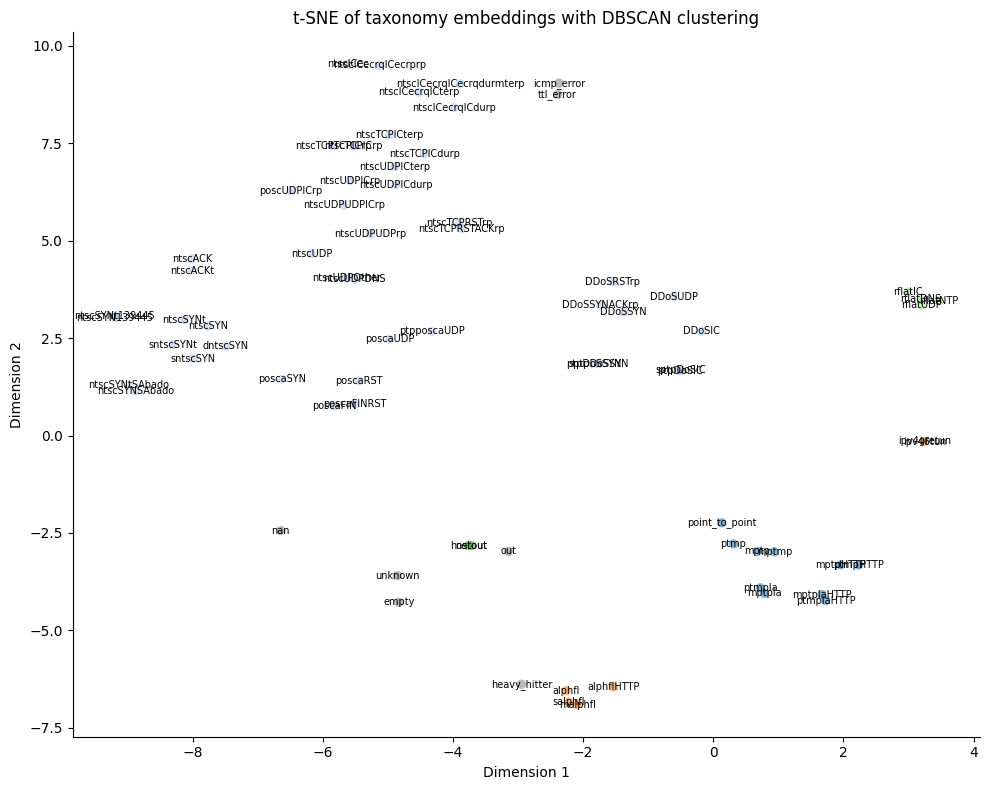

In [18]:
color_palette = sns.color_palette("tab20", n_clusters_)
fig, ax = plt.subplots(figsize=(10,8))
sns.scatterplot(
    data=taxonomies,
    x='tsne2d_x',
    y='tsne2d_y',
    color=[color_palette[label] if label != -1 else (0.5,0.5,0.5) for label in taxonomies['dbscan_cluster']],
    s=45, alpha=0.55, linewidth=0, ax=ax
)

for xi, yi, abbr in zip(taxonomies.tsne2d_x, taxonomies.tsne2d_y, taxonomies.abbreviation):
    ax.text(xi, yi, abbr, fontsize=7, ha='center', va='center')


ax.set(title="t-SNE of taxonomy embeddings with DBSCAN clustering")
ax.set_xlabel("Dimension 1")
ax.set_ylabel("Dimension 2")
sns.despine()
plt.tight_layout()

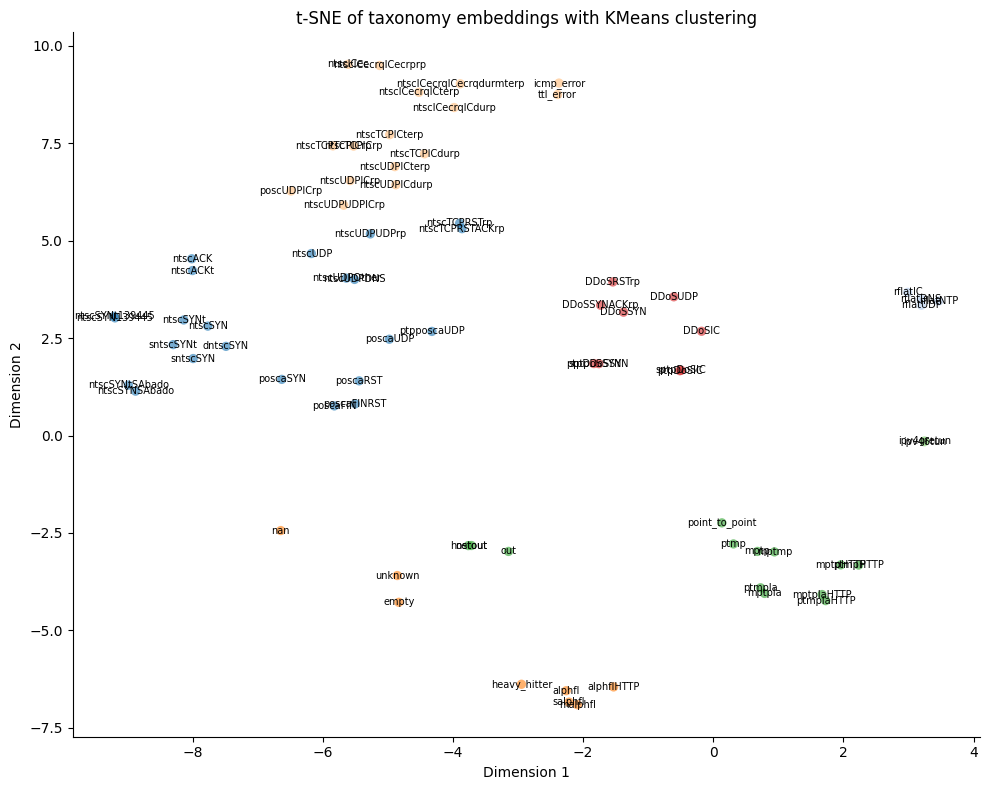

In [19]:
color_palette = sns.color_palette("tab20", best_k)
fig, ax = plt.subplots(figsize=(10,8))
sns.scatterplot(
    x='tsne2d_x', y='tsne2d_y',
    data=taxonomies,
    hue='kmeans_cluster',
    palette=color_palette,
    s=45, linewidth=0, alpha=0.6, ax=ax,
    legend=False
)

for xi, yi, abbr in zip(taxonomies.tsne2d_x, taxonomies.tsne2d_y, taxonomies.abbreviation):
    ax.text(xi, yi, abbr, fontsize=7, ha='center', va='center')


ax.set(title="t-SNE of taxonomy embeddings with KMeans clustering")
ax.set_xlabel("Dimension 1")
ax.set_ylabel("Dimension 2")
sns.despine()
plt.tight_layout()

In [21]:
taxonomies.to_csv("../taxonomies.csv")